- open the 90 GHz and 150 GHz bands
- see that the 150 GHz have the angles
- plot all their positions with the angles
- plot their snrs?

# notes
- runs/obs 1 and 4 share same boresight rotation and so the same HWP position
- Other pairs are: obs 2 and 5
- obs 3 and 6

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pickle
import pandas as pd
from matplotlib.markers import MarkerStyle

In [73]:
import matplotlib.cm as cm
import matplotlib.colors as mcolors

In [45]:
# # Basic imports
# # import numpy as np
# # import matplotlib.pyplot as plt
# import os

# # For loading contexts
# from sotodlib import core

# import pprint
# import sys
# import glob
# import yaml
# import time
# import datetime as dt
# import matplotlib as mpl
# import scipy.signal as signal
# import scipy.optimize as opt
# from scipy import stats
# from latrt_testing import utils
# import latrt_testing.demodulation as demod
# from random import randrange
# import latrt_testing.fft_ops as fft_ops
# from so3g.hk import load_range

# from sotodlib.io.load_smurf import * 
# from sotodlib.tod_ops.fft_ops import rfft
# from sotodlib.tod_ops.detrend import detrend_tod
# from sotodlib.tod_ops import pca
# from sotodlib.io import load_smurf
# from sotodlib.io import hkdb

# import logging
# logger.setLevel(logging.DEBUG)

# import sotodlib
# from sotodlib.tod_ops.flags import get_glitch_flags, get_trending_flags
# import importlib
# from scipy.optimize import curve_fit

# from sotodlib.tod_ops import flags, detrend_tod, jumps, gapfill, pca, filters, apodize, fft_ops
# from sotodlib.core.flagman import has_any_cuts, has_all_cut
# from pixell import utils
# from scipy.signal import welch
# from scipy.signal import hilbert

# # from matplotlib.markers import MarkerStyle
# import scipy
# # import pickle

Loaded new demodulation.py


/global/homes/s/shreyasu/lart_testing_env/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# 1.a. load stored bands data

In [24]:
fname90_run2 = '/global/homes/s/shreyasu/SAT FTS Analysis 202602/FTS_data_mv19/band_attrs_obs2_90GHz_pW_260818.pkl'
fname90_run3 = '/global/homes/s/shreyasu/SAT FTS Analysis 202602/FTS_data_mv19/band_attrs_obs3_90GHz_pW_260818.pkl'
fname90_run5 = '/global/homes/s/shreyasu/SAT FTS Analysis 202602/FTS_data_mv19/band_attrs_obs5_90GHz_pW_260818.pkl'
fname90_run6 = '/global/homes/s/shreyasu/SAT FTS Analysis 202602/FTS_data_mv19/band_attrs_obs6_90GHz_pW_260818.pkl'

fname150_run2 = '/global/homes/s/shreyasu/SAT FTS Analysis 202602/FTS_data_mv19/band_attrs_obs2_150GHz_pW_260818.pkl'
fname150_run3 = '/global/homes/s/shreyasu/SAT FTS Analysis 202602/FTS_data_mv19/band_attrs_obs3_150GHz_pW_260818.pkl'
fname150_run5 = '/global/homes/s/shreyasu/SAT FTS Analysis 202602/FTS_data_mv19/band_attrs_obs5_150GHz_pW_260818.pkl'
fname150_run6 = '/global/homes/s/shreyasu/SAT FTS Analysis 202602/FTS_data_mv19/band_attrs_obs6_150GHz_pW_260818.pkl'

In [25]:
with open(fname90_run2,'rb') as f:
    data90_run2 = pickle.load(f)
    
with open(fname90_run3,'rb') as f:
    data90_run3 = pickle.load(f)

with open(fname90_run5,'rb') as f:
    data90_run5 = pickle.load(f)

with open(fname90_run6,'rb') as f:
    data90_run6 = pickle.load(f)

In [27]:
with open(fname150_run2,'rb') as f:
    data150_run2 = pickle.load(f)

with open(fname150_run3,'rb') as f:
    data150_run3 = pickle.load(f)

with open(fname150_run5,'rb') as f:
    data150_run5 = pickle.load(f)

with open(fname150_run6,'rb') as f:
    data150_run6 = pickle.load(f)

In [28]:
data150_run6['passband_results'][0].keys()

dict_keys(['det_name', 'det_band', 'det_channel', 'band', 'frequency_ghz', 'snr_local', 'local_ind', 'xi', 'eta', 'gamma', 'angles'])

In [43]:
data90_run6['obs_id']

'obs_1766073664_satp1_1111111'

In [44]:
# load just the whole mv19 (ws0) detectors
obs_id_mv19_90ghz = data90_run2['obs_id']
obs_id_mv19_150ghz = data150_run2['obs_id']

## 1.b. load full array detector positions

In [87]:
with open('/global/homes/s/shreyasu/SAT FTS Analysis 202602/FTS_data_mv19/mv19_all90s_positions.pkl', 'rb') as f:
    mv19_all90s_positions = pickle.load(f)

with open('/global/homes/s/shreyasu/SAT FTS Analysis 202602/FTS_data_mv19/mv19_all150s_positions.pkl', 'rb') as f:
    mv19_all150s_positions = pickle.load(f)

In [47]:
# # Get path to the context
# platform = "satp1"
# site = "nersc"

# match site:
#     case "nersc":
#         base_path = f"/global/cfs/cdirs/sobs/metadata/{platform}/"
#     case "site":
#         base_path = f"/so/metadata/{platform}/"
#     case "tiger3":
#         base_path = f"/scratch/gpfs/SIMONSOBS/so/tracked/metadata/{platform}/"
#     case "manchester":
#         base_path = f"/cephfs/soukdata/data/tracked/metadata/{platform}/"

# context_path = os.path.join(base_path, "contexts/use_this_local.yaml" if site != "site" else "contexts/use_this.yaml")
# # print(context_path)
# context = core.Context(context_path)

In [49]:
# dets_mv19_all90 = {'wafer_slot': 'ws0', 'wafer.bandpass':'f090'}
# obs_mv19_90ghz = context.get_obs(str(obs_id_mv19_90ghz), dets_mv19_all90)

# dets_mv19_all150 = {'wafer_slot': 'ws0', 'wafer.bandpass':'f150'}
# obs_mv19_150ghz = context.get_obs(str(obs_id_mv19_150ghz), dets_mv19_all150)

In [62]:
# # store 90s positions and angles
# xi_all90s = obs_mv19_90ghz.focal_plane.xi.copy()
# eta_all90s = obs_mv19_90ghz.focal_plane.eta.copy()
# gamma_all90s = obs_mv19_90ghz.focal_plane.gamma.copy()
# angles_all90s = obs_mv19_90ghz.det_info.wafer.angle.copy()

In [61]:
# # store 150s positions and angles
# xi_all150s = obs_mv19_150ghz.focal_plane.xi.copy()
# eta_all150s = obs_mv19_150ghz.focal_plane.eta.copy()
# gamma_all150s = obs_mv19_150ghz.focal_plane.gamma.copy()
# angles_all150s = obs_mv19_150ghz.det_info.wafer.angle.copy()

In [53]:
# # store positions and angles for easier access
# mv19_all90s_positions = {'xi': xi_all90s, 
#                         'eta': eta_all90s,
#                         'gamma': gammas_all90s,
#                         'angles': angles_all90s}

# mv19_all150s_positions = {'xi': xi_all150s, 
#                         'eta': eta_all150s,
#                         'gamma': gammas_all150s,
#                         'angles': angles_all150s}

In [55]:
# with open('/global/homes/s/shreyasu/SAT FTS Analysis 202602/FTS_data_mv19/mv19_all90s_positions.pkl', 'wb') as f:
#     pickle.dump(mv19_all90s_positions, f)

In [56]:
# with open('/global/homes/s/shreyasu/SAT FTS Analysis 202602/FTS_data_mv19/mv19_all150s_positions.pkl', 'wb') as f:
#     pickle.dump(mv19_all150s_positions, f)

# 2. preprocess data

In [32]:
# 90 GHz
results90_run2 = data90_run2['passband_results']

xi_90_run2    = np.array([r['xi']    for r in results90_run2])
eta_90_run2   = np.array([r['eta']   for r in results90_run2])
gamma_90_run2 = np.array([r['gamma'] for r in results90_run2])
angles_90_run2 = np.array([r['angles'] for r in results90_run2])

In [70]:
snrs_90_run2 = np.array([r['snr_local'] for r in results90_run2])

In [33]:
results90_run3 = data90_run3['passband_results']

xi_90_run3    = np.array([r['xi']    for r in results90_run3])
eta_90_run3   = np.array([r['eta']   for r in results90_run3])
gamma_90_run3 = np.array([r['gamma'] for r in results90_run3])
angles_90_run3 = np.array([r['angles'] for r in results90_run3])

In [67]:
snrs_90_run3 = np.array([r['snr_local'] for r in results90_run3])


In [34]:
results90_run5 = data90_run5['passband_results']

xi_90_run5    = np.array([r['xi']    for r in results90_run5])
eta_90_run5   = np.array([r['eta']   for r in results90_run5])
gamma_90_run5 = np.array([r['gamma'] for r in results90_run5])
angles_90_run5 = np.array([r['angles'] for r in results90_run5])

In [69]:
snrs_90_run5 = np.array([r['snr_local'] for r in results90_run5])


In [35]:
results90_run6 = data90_run6['passband_results']

xi_90_run6    = np.array([r['xi']    for r in results90_run6])
eta_90_run6   = np.array([r['eta']   for r in results90_run6])
gamma_90_run6 = np.array([r['gamma'] for r in results90_run6])
angles_90_run6 = np.array([r['angles'] for r in results90_run6])

In [71]:
snrs_90_run6 = np.array([r['snr_local'] for r in results90_run6])


In [36]:
# 150 GHz
results150_run2 = data150_run2['passband_results']

xi_150_run2    = np.array([r['xi']    for r in results150_run2])
eta_150_run2   = np.array([r['eta']   for r in results150_run2])
gamma_150_run2 = np.array([r['gamma'] for r in results150_run2])
angles_150_run2 = np.array([r['angles'] for r in results150_run2])

results150_run3 = data150_run3['passband_results']

xi_150_run3    = np.array([r['xi']    for r in results150_run3])
eta_150_run3   = np.array([r['eta']   for r in results150_run3])
gamma_150_run3 = np.array([r['gamma'] for r in results150_run3])
angles_150_run3 = np.array([r['angles'] for r in results150_run3])

results150_run5 = data150_run5['passband_results']

xi_150_run5    = np.array([r['xi']    for r in results150_run5])
eta_150_run5   = np.array([r['eta']   for r in results150_run5])
gamma_150_run5 = np.array([r['gamma'] for r in results150_run5])
angles_150_run5 = np.array([r['angles'] for r in results150_run5])

results150_run6 = data150_run6['passband_results']

xi_150_run6    = np.array([r['xi']    for r in results150_run6])
eta_150_run6   = np.array([r['eta']   for r in results150_run6])
gamma_150_run6 = np.array([r['gamma'] for r in results150_run6])
angles_150_run6 = np.array([r['angles'] for r in results150_run6])

In [74]:
snrs_150_run2 = np.array([r['snr_local'] for r in results150_run2])
snrs_150_run3 = np.array([r['snr_local'] for r in results150_run3])
snrs_150_run5 = np.array([r['snr_local'] for r in results150_run5])
snrs_150_run6 = np.array([r['snr_local'] for r in results150_run6])

In [88]:
# plt.figure()
# plt.hist(angles_90_run6)
# plt.show()

# 3. plot pol angles

- plotting the 90 GHz dets for now

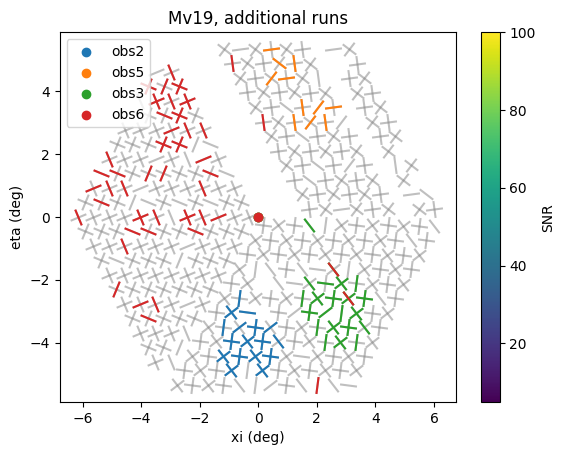

In [86]:

fig, ax = plt.subplots()

# shared snr normalization across runs
all_snrs90 = np.concatenate([snrs_90_run2, snrs_90_run3,snrs_90_run5 , snrs_90_run6])
# all_snrs150 = np.concatenate([snrs_90_run2, snrs_90_run3,snrs_90_run5 , snrs_90_run6])

norm = mcolors.Normalize(vmin=5, vmax=100) # all_snrs90.max()
cmap = cm.viridis  # pick whatever colormap you like

# all 90s
for x, y, angle in zip(np.degrees(xi_all90s), np.degrees(eta_all90s), np.degrees(gamma_all90s)):
    marker = MarkerStyle('|').rotated(deg=angle)
    ax.scatter(x, y, marker=marker, color='grey', alpha=0.5, s=150)

# for x, y, angle in zip(np.degrees(xi_all150s), np.degrees(eta_all150s), np.degrees(gamma_all150s)):
#     marker = MarkerStyle('|').rotated(deg=angle)
#     plt.scatter(x, y, marker=marker, color='grey', alpha=0.5, s=150)

# pair 2
for x, y, angle, snr in zip(np.degrees(xi_90_run2), np.degrees(eta_90_run2), np.degrees(gamma_90_run2), snrs_90_run2):
    marker = MarkerStyle('|').rotated(deg=angle)
    ax.scatter(x, y, marker=marker, color='C0', alpha=1, s=150) # cmap(norm(snr))

for x, y, angle, snr in zip(np.degrees(xi_90_run5), np.degrees(eta_90_run5), np.degrees(gamma_90_run5), snrs_90_run5):
    marker = MarkerStyle('|').rotated(deg=angle)
    ax.scatter(x, y, marker=marker, color='C1', alpha=1, s=150) # cmap(norm(snr))

ax.scatter(0, 0, color='C0', label='obs2')
ax.scatter(0, 0, color='C1', label='obs5')

# pair 3
for x, y, angle, snr in zip(np.degrees(xi_90_run3), np.degrees(eta_90_run3), np.degrees(gamma_90_run3), snrs_90_run3):
    marker = MarkerStyle('|').rotated(deg=angle)
    ax.scatter(x, y, marker=marker, color='C2', alpha=1, s=150) # cmap(norm(snr))
    
for x, y, angle, snr in zip(np.degrees(xi_90_run6), np.degrees(eta_90_run6), np.degrees(gamma_90_run6), snrs_90_run6):
    marker = MarkerStyle('|').rotated(deg=angle)
    ax.scatter(x, y, marker=marker, color='C3', alpha=1, s=150) # cmap(norm(snr))

ax.scatter(0, 0, color='C2', label='obs3')
ax.scatter(0, 0, color='C3', label='obs6')

# add a colorbar using a ScalarMappable tied to the same norm/cmap
sm = cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])
fig.colorbar(sm, ax=ax, label='SNR')

ax.legend()
ax.set_title('Mv19, additional runs')
ax.set_xlabel('xi (deg)')
ax.set_ylabel('eta (deg)')
plt.show()